# Reconstruct the Coinbase Level 2 order book

This notebook loads the newest saved `SOL-USD` Level 2 capture, builds the book from its opening snapshot, applies every update in file order, and records one-second book features. Coinbase quantities replace the entire quantity at a price level; a zero quantity removes that level.

The resulting table contains Coinbase event time, local receipt time, event-to-receipt delay, best bid/ask, spread, mid-price, top-10 depth, imbalance, and basic consistency checks. It represents aggregated price levels—not individual orders or queue positions.

In [1]:
from heapq import heapify, heappop, heappush
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Analysis settings. Increase DEPTH_LEVELS to measure deeper book liquidity.
DATA_DIR = Path("../data/ticks")
PRODUCT_ID = "SOL-USD"
SAMPLE_SECONDS = 1
DEPTH_LEVELS = 10
SUSPICIOUS_GAP_SECONDS = 5

# Select the newest Level 2 capture produced by the collection notebook.
files = sorted(DATA_DIR.glob(f"coinbase_{PRODUCT_ID}_level2_*.csv"))
if not files:
    raise FileNotFoundError(f"No Level 2 captures found in {DATA_DIR.resolve()}")
LEVEL2_PATH = files[-1]
print(f"Using {LEVEL2_PATH.resolve()}")

Using /Users/hankrugg/Fordham/Fall26/Crypto/trading/data/ticks/coinbase_SOL-USD_level2_20261009T133847Z.csv


In [2]:
# Load only the fields needed to rebuild the book, which keeps memory use down.
columns = [
    "event_type", "event_time", "received_at_ns", "side",
    "price_level", "new_quantity", "sequence_num",
]
level2 = pd.read_csv(
    LEVEL2_PATH,
    usecols=columns,
    dtype={
        "event_type": "category", "side": "category",
        "received_at_ns": "int64", "sequence_num": "int64",
        "price_level": "float64", "new_quantity": "float64",
    },
)
level2["event_time"] = pd.to_datetime(level2["event_time"], utc=True)

# Reconstruction is only valid when it starts from a complete snapshot.
if level2.empty or level2.iloc[0]["event_type"] != "snapshot":
    raise ValueError("The capture must begin with a Level 2 snapshot.")
if (level2["new_quantity"] < 0).any():
    raise ValueError("Negative quantities found in the capture.")
if not set(level2["side"].dropna()).issubset({"bid", "offer"}):
    raise ValueError("Unexpected side value found in the capture.")

# Many price-level rows can belong to one WebSocket message. Keep one row per
# sequence number here so timing and ordering are checked at message level.
messages = level2[["sequence_num", "received_at_ns"]].drop_duplicates("sequence_num")
messages["receive_gap_seconds"] = messages["received_at_ns"].diff() / 1e9
long_gaps = messages[messages["receive_gap_seconds"] > SUSPICIOUS_GAP_SECONDS]
out_of_order = int((messages["sequence_num"].diff() <= 0).sum())

print(f"Loaded {len(level2):,} price-level rows across {len(messages):,} stored messages")
print(f"Snapshot rows: {(level2.event_type == 'snapshot').sum():,}")
print(f"Out-of-order stored messages: {out_of_order:,}")
print(f"Receive gaps over {SUSPICIOUS_GAP_SECONDS}s: {len(long_gaps):,}")

Loaded 942,749 price-level rows across 138,461 stored messages
Snapshot rows: 26,234
Out-of-order stored messages: 0
Receive gaps over 5s: 0


In [3]:
def reconstruct_book(rows, sample_seconds=1, depth_levels=10):
    """Replay snapshot/update rows and return sampled metrics plus the final book."""

    # The dictionaries are the authoritative order book: price -> quantity.
    books = {"bid": {}, "offer": {}}

    # A price receives a new version each time it changes. Old heap entries can
    # then be recognized as stale without removing them immediately.
    versions = {"bid": {}, "offer": {}}

    # Heaps provide fast access to the highest bids and lowest offers.
    heaps = {"bid": [], "offer": []}
    samples = []
    # Coinbase receive times are stored as integer nanoseconds.
    sample_ns = int(sample_seconds * 1e9)
    next_sample_ns = None
    current_sequence = None
    current_received_ns = None
    current_event_time = None
    saw_snapshot = False

    def rebuild_heap(side):
        # Completely replace one heap using only currently active price levels.
        # Bid prices are negated because Python supplies a min-heap, while the
        # best bid is the highest price. Offers naturally use the lowest price.
        sign = -1 if side == "bid" else 1
        heaps[side] = [
            (sign * price, versions[side][price], price)
            for price in books[side]
        ]
        heapify(heaps[side])

    def set_level(side, price, quantity):
        # Mark this as the newest state for the price level.
        version = versions[side].get(price, 0) + 1
        versions[side][price] = version
        # Coinbase sends the complete replacement quantity, not a quantity delta.
        # A zero quantity means the price level no longer exists.
        if quantity == 0:
            books[side].pop(price, None)
        else:
            books[side][price] = quantity
            # Add the new version to the heap. Any older version stays there
            # temporarily and will be ignored by top_levels().
            key = -price if side == "bid" else price
            heappush(heaps[side], (key, version, price))
        # Occasionally remove accumulated stale entries to control memory use.
        if len(heaps[side]) > max(2 * len(books[side]), len(books[side]) + 50_000):
            rebuild_heap(side)

    def top_levels(side):
        # Pop heap entries until the requested number of current levels is found.
        # An entry is current only when its version matches versions[side][price].
        valid_entries = []
        levels = []
        heap = heaps[side]
        book = books[side]
        side_versions = versions[side]
        while heap and len(levels) < depth_levels:
            entry = heappop(heap)
            _, version, price = entry
            if price in book and side_versions.get(price) == version:
                valid_entries.append(entry)
                levels.append((price, book[price]))
        # Valid entries were removed only for inspection, so put them back.
        for entry in valid_entries:
            heappush(heap, entry)
        return levels

    def finish_message(sequence, received_ns, event_time):
        # This runs only after every price change in a WebSocket message has been
        # applied, so a sample never represents a partially applied message.
        nonlocal next_sample_ns
        if not saw_snapshot:
            return
        if next_sample_ns is None:
            next_sample_ns = received_ns
        # Most messages update the book without creating an output row. Record
        # only the first complete state at or after each sampling boundary.
        if received_ns < next_sample_ns:
            return

        top_bids = top_levels("bid")
        top_offers = top_levels("offer")
        if top_bids and top_offers:
            best_bid, best_bid_size = top_bids[0]
            best_ask, best_ask_size = top_offers[0]
            bid_depth = sum(quantity for _, quantity in top_bids)
            ask_depth = sum(quantity for _, quantity in top_offers)
            total_depth = bid_depth + ask_depth
            # Positive imbalance means the top levels contain more bid quantity;
            # negative imbalance means they contain more offer quantity.
            samples.append({
                # event_time is assigned by Coinbase; received_at_ns is when
                # this computer observed the completed WebSocket message.
                "event_time": event_time,
                "received_at_ns": received_ns,
                "sequence_num": sequence,
                "best_bid": best_bid,
                "best_ask": best_ask,
                "best_bid_size": best_bid_size,
                "best_ask_size": best_ask_size,
                "spread": best_ask - best_bid,
                "mid_price": (best_bid + best_ask) / 2,
                f"bid_depth_{depth_levels}": bid_depth,
                f"ask_depth_{depth_levels}": ask_depth,
                f"imbalance_{depth_levels}": (bid_depth - ask_depth) / total_depth
                    if total_depth else float("nan"),
                "bid_levels": len(books["bid"]),
                "ask_levels": len(books["offer"]),
                "crossed_book": best_bid >= best_ask,
            })
        # Advance past every elapsed boundary without inventing observations for
        # periods in which no stored Level 2 message was available.
        next_sample_ns += ((received_ns - next_sample_ns) // sample_ns + 1) * sample_ns

    # Replay rows in their original collection order. Rows sharing a sequence
    # number are treated as parts of the same WebSocket message.
    for row in rows.itertuples(index=False):
        if row.sequence_num != current_sequence:
            if current_sequence is not None:
                finish_message(current_sequence, current_received_ns, current_event_time)
            current_sequence = row.sequence_num
            current_received_ns = row.received_at_ns
            current_event_time = row.event_time
            if row.event_type == "snapshot":
                # A snapshot replaces all previous state and becomes the new base.
                books = {"bid": {}, "offer": {}}
                versions = {"bid": {}, "offer": {}}
                heaps = {"bid": [], "offer": []}
                saw_snapshot = True
        # If one message contains several update times, associate its completed
        # book state with the latest exchange event included in that message.
        if row.event_time > current_event_time:
            current_event_time = row.event_time

        # Apply this snapshot level or incremental update to the correct side.
        set_level(row.side, row.price_level, row.new_quantity)

    if current_sequence is not None:
        finish_message(current_sequence, current_received_ns, current_event_time)

    # Convert the collected feature dictionaries into a backtest-friendly table.
    metrics = pd.DataFrame(samples)
    metrics["received_at"] = pd.to_datetime(metrics["received_at_ns"], unit="ns", utc=True)
    metrics["event_to_receive_ms"] = (
        metrics["received_at"] - metrics["event_time"]
    ).dt.total_seconds() * 1_000
    return metrics, books

book_metrics, final_book = reconstruct_book(level2, SAMPLE_SECONDS, DEPTH_LEVELS)
display(book_metrics.head())

,event_time,received_at_ns,sequence_num,best_bid,best_ask,best_bid_size,best_ask_size,spread,mid_price,bid_depth_10,ask_depth_10,imbalance_10,bid_levels,ask_levels,crossed_book,received_at,event_to_receive_ms
0,2026-10-09 10:38:46.321411+00:00,1791542326505635000,2,109.6,109.62,63.133094,80.545522,0.02,109.61,2537.544435,1891.049330,0.145982,4062,9056,False,2026-10-09 10:38:46.505635+00:00,184.224
1,2026-10-09 10:38:47.536561+00:00,1791542327554103000,25,109.6,109.62,63.133094,41.610000,0.02,109.61,2534.097085,1718.814963,0.191700,4063,9056,False,2026-10-09 10:38:47.554103+00:00,17.542
2,2026-10-09 10:38:48.477619+00:00,1791542328583365000,42,109.6,109.62,69.280735,41.610000,0.02,109.61,2753.824667,1288.238156,0.362584,4062,9056,False,2026-10-09 10:38:48.583365+00:00,105.746
3,2026-10-09 10:38:49.531141+00:00,1791542329544308000,54,109.6,109.62,63.972227,42.658605,0.02,109.61,2522.030757,1470.049479,0.263517,4061,9056,False,2026-10-09 10:38:49.544308+00:00,13.167
4,2026-10-09 10:38:50.496621+00:00,1791542330545895000,69,109.6,109.62,63.972227,42.549136,0.02,109.61,2856.709737,1642.647349,0.269830,4061,9055,False,2026-10-09 10:38:50.545895+00:00,49.274


Created 10,724 one-second book observations
Final active levels: 4,057 bids, 9,039 asks
Crossed-book observations: 0
Largest receive gap: 1.712 seconds


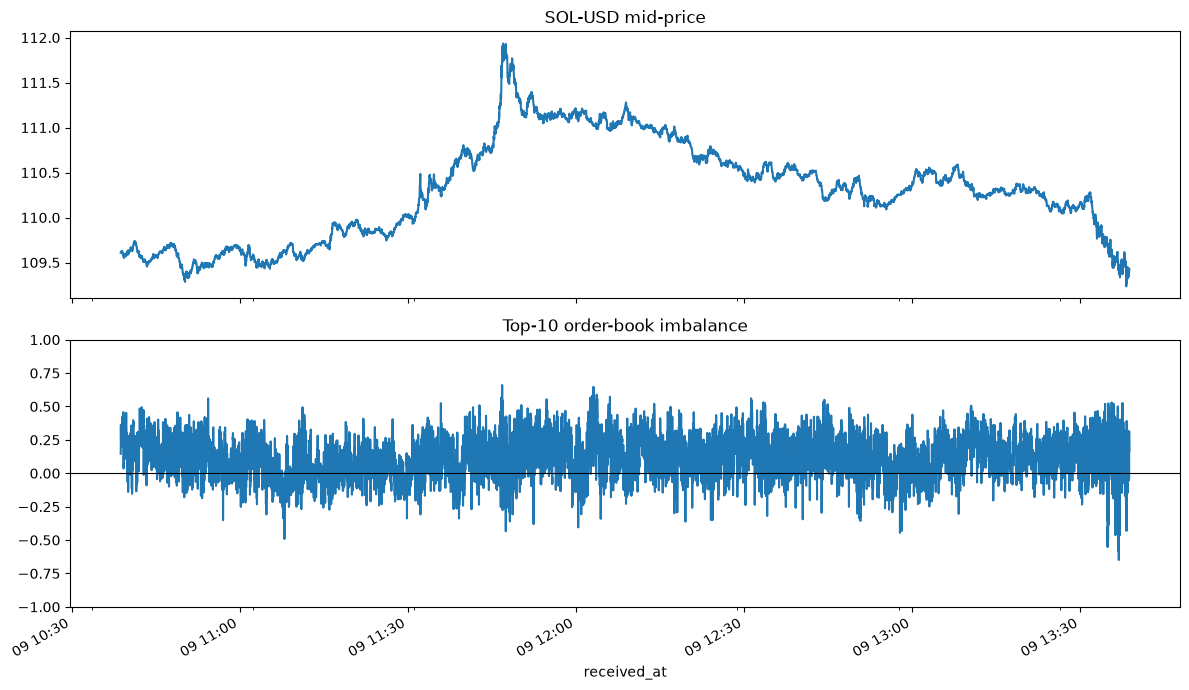

In [4]:
# Summarize reconstruction quality before using these features in a backtest.
max_gap = messages["receive_gap_seconds"].max()
print(f"Created {len(book_metrics):,} one-second book observations")
print(f"Final active levels: {len(final_book['bid']):,} bids, {len(final_book['offer']):,} asks")
print(f"Crossed-book observations: {book_metrics['crossed_book'].sum():,}")
print(f"Largest receive gap: {max_gap:.3f} seconds")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
book_metrics.plot(x="received_at", y="mid_price", ax=axes[0], legend=False, title="SOL-USD mid-price")
book_metrics.plot(x="received_at", y=f"imbalance_{DEPTH_LEVELS}", ax=axes[1], legend=False, title=f"Top-{DEPTH_LEVELS} order-book imbalance")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylim(-1, 1)
plt.tight_layout()
plt.show()

Sequence-number jumps are not treated as dropped data here because the collector flattened only messages containing price-level rows; empty Level 2 envelopes were not saved. A later production collector should preserve every raw message envelope so sequence continuity can be audited exactly.

In [5]:
# Keep the timestamp from the source filename so captures and features match.
metrics_path = LEVEL2_PATH.with_name(LEVEL2_PATH.name.replace("_level2_", "_book_metrics_"))
book_metrics.to_csv(metrics_path, index=False)
print(f"Saved reconstructed features to {metrics_path.resolve()}")

Saved reconstructed features to /Users/hankrugg/Fordham/Fall26/Crypto/trading/data/ticks/coinbase_SOL-USD_book_metrics_20261009T133847Z.csv
